#Import & Load

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/European_Bank.csv')
print(df.shape)

(10000, 14)


#Check column Types

In [2]:
print(df.dtypes)

Year                 int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


#Check for Nulls

In [3]:
print(df.isnull().sum())

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


#Check churn distribution

In [4]:
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True).round(3))

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


#Preview the data

In [5]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#Drop Unnecessary Columns

In [6]:
df.drop(columns=['Surname', 'CustomerId', 'Year'], inplace=True)
print(df.shape)  # should now be (10000, 11)
print(df.columns.tolist())

(10000, 11)
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


#Verify binary fields are clean

In [7]:
assert df['Exited'].isin([0,1]).all(), "Exited has unexpected values"
assert df['HasCrCard'].isin([0,1]).all(), "HasCrCard has unexpected values"
assert df['IsActiveMember'].isin([0,1]).all(), "IsActiveMember has unexpected values"
print("All binary fields are clean ✓")

All binary fields are clean ✓


#Age groups

In [8]:
df['AgeGroup'] = pd.cut(df['Age'],
    bins=[0, 29, 45, 60, 120],
    labels=['<30', '30-45', '46-60', '60+'])

print(df['AgeGroup'].value_counts())

AgeGroup
30-45    6248
46-60    1647
<30      1641
60+       464
Name: count, dtype: int64


#Credit score bands

In [9]:
df['CreditBand'] = pd.cut(df['CreditScore'],
    bins=[299, 579, 669, 739, 850],
    labels=['Low', 'Medium', 'High', 'Very High'])

print(df['CreditBand'].value_counts())

CreditBand
Medium       3331
High         2428
Low          2362
Very High    1879
Name: count, dtype: int64


#Tenure groups

In [10]:
df['TenureGroup'] = pd.cut(df['Tenure'],
    bins=[-1, 2, 6, 10],
    labels=['New', 'Mid-term', 'Long-term'])

print(df['TenureGroup'].value_counts())

TenureGroup
Mid-term     3977
Long-term    3527
New          2496
Name: count, dtype: int64


#Balance segments

In [11]:
df['BalanceSegment'] = pd.cut(df['Balance'],
    bins=[-1, 0, 50000, 300000],
    labels=['Zero', 'Low', 'High'])

print(df['BalanceSegment'].value_counts())

BalanceSegment
High    6308
Zero    3617
Low       75
Name: count, dtype: int64


#Create high-value flag

In [12]:
threshold = df['Balance'].quantile(0.75)
df['IsHighValue'] = (df['Balance'] >= threshold).astype(int)

print(f"High-value threshold: £{threshold:,.2f}")
print(df['IsHighValue'].value_counts())
print(f"\nHigh-value customers: {df['IsHighValue'].mean()*100:.1f}% of total")

High-value threshold: £127,644.24
IsHighValue
0    7500
1    2500
Name: count, dtype: int64

High-value customers: 25.0% of total


#Quick sanity check on all new columns

In [13]:
print(df.shape)  # should be (10000, 16)
df[['AgeGroup','CreditBand','TenureGroup','BalanceSegment','IsHighValue']].head(10)

(10000, 16)


,AgeGroup,CreditBand,TenureGroup,BalanceSegment,IsHighValue
0,30-45,Medium,New,Zero,0
1,30-45,Medium,New,High,0
2,30-45,Low,Long-term,High,1
3,30-45,High,New,Zero,0
4,30-45,Very High,New,High,0
5,30-45,Medium,Long-term,High,0
6,46-60,Very High,Long-term,Zero,0
7,<30,Low,Mid-term,High,0
8,30-45,Low,Mid-term,High,1
9,<30,High,New,High,1


#Headline churn number

In [14]:
churn_rate = df['Exited'].mean() * 100
total_churned = df['Exited'].sum()
total_retained = len(df) - total_churned

print(f"Overall Churn Rate : {churn_rate:.1f}%")
print(f"Total Churned      : {total_churned}")
print(f"Total Retained     : {total_retained}")

Overall Churn Rate : 20.4%
Total Churned      : 2037
Total Retained     : 7963


#Visualise churn distribution

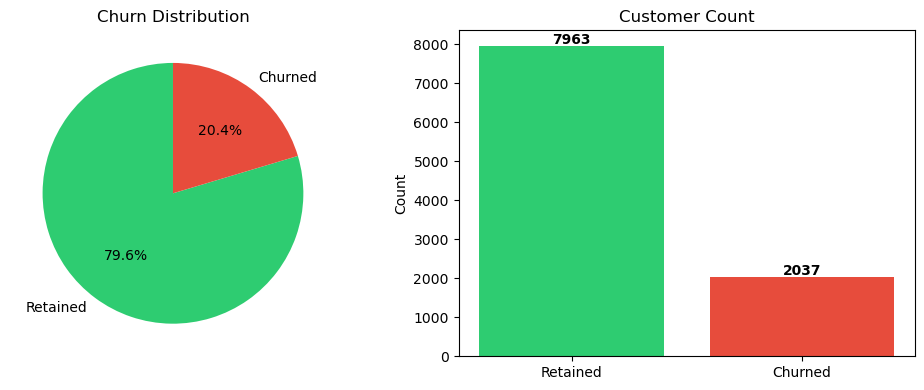

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart
axes[0].pie([total_retained, total_churned],
            labels=['Retained', 'Churned'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[0].set_title('Churn Distribution')

# Bar chart
axes[1].bar(['Retained', 'Churned'],
            [total_retained, total_churned],
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Customer Count')
axes[1].set_ylabel('Count')
for i, v in enumerate([total_retained, total_churned]):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/churn_distribution.png', dpi=150)
plt.show()

#Churn rate by Geography

In [16]:
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
print(geo_churn.round(1))

Geography
France     16.2
Germany    32.4
Spain      16.7
Name: Exited, dtype: float64


#Churn rate by Gender

In [17]:
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
print(gender_churn.round(1))

Gender
Female    25.1
Male      16.5
Name: Exited, dtype: float64


#Visualise both

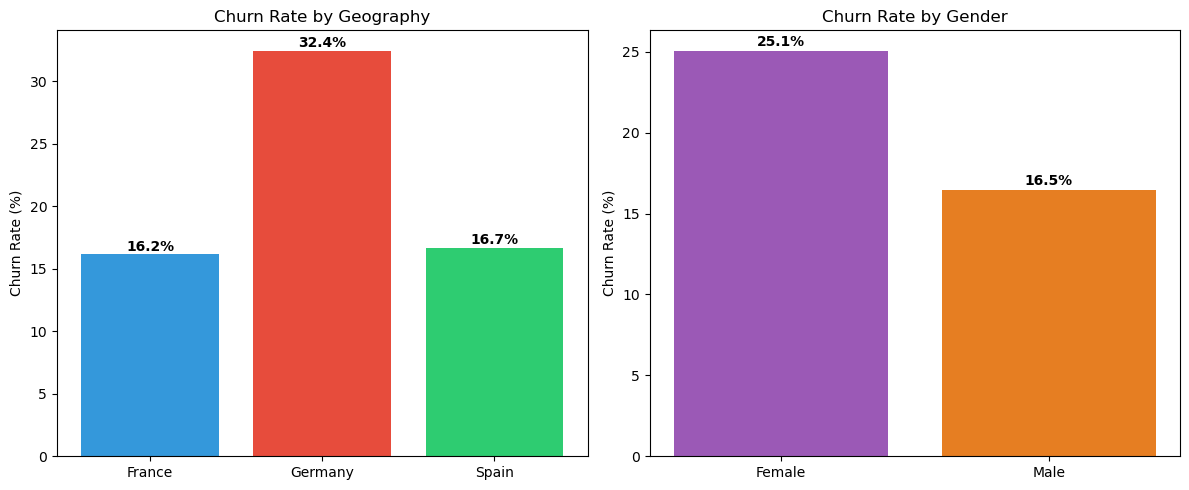

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Geography
colors_geo = ['#3498db', '#e74c3c', '#2ecc71']
axes[0].bar(geo_churn.index, geo_churn.values, color=colors_geo)
axes[0].set_title('Churn Rate by Geography')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(geo_churn.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Gender
colors_gen = ['#9b59b6', '#e67e22']
axes[1].bar(gender_churn.index, gender_churn.values, color=colors_gen)
axes[1].set_title('Churn Rate by Gender')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(gender_churn.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/geo_gender_churn.png', dpi=150)
plt.show()

#Geography × Gender combined

Gender     Female  Male
Geography              
France       20.3  12.7
Germany      37.6  27.8
Spain        21.2  13.1


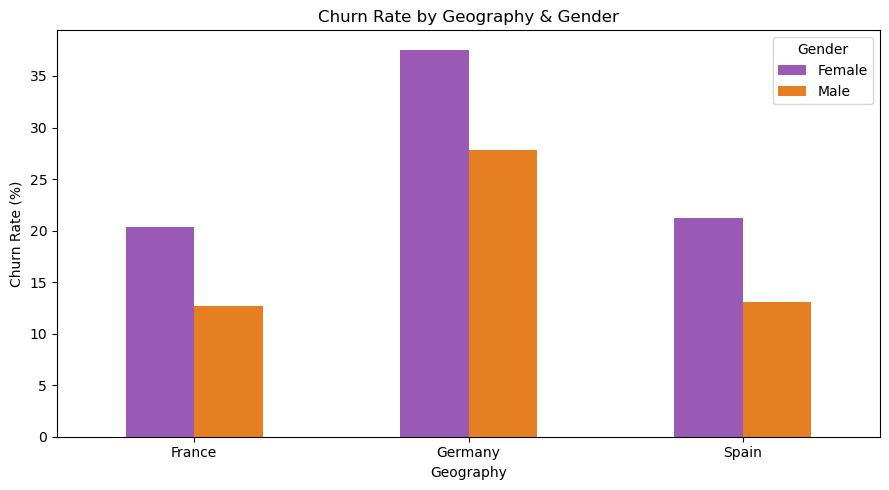

In [19]:
cross = df.groupby(['Geography', 'Gender'])['Exited'].mean().unstack() * 100
print(cross.round(1))

cross.plot(kind='bar', figsize=(9, 5), color=['#9b59b6', '#e67e22'], rot=0)
plt.title('Churn Rate by Geography & Gender')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('../assets/geo_gender_cross.png', dpi=150)
plt.show()

#Churn by Age Group

In [20]:
age_churn = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100
print(age_churn.round(1))

AgeGroup
<30       7.6
30-45    15.3
46-60    51.1
60+      24.8
Name: Exited, dtype: float64


#Churn by Tenure Group

In [21]:
tenure_churn = df.groupby('TenureGroup', observed=True)['Exited'].mean() * 100
print(tenure_churn.round(1))

TenureGroup
New          21.2
Mid-term     20.6
Long-term    19.5
Name: Exited, dtype: float64


#Churn by Number of Products

In [22]:
product_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
print(product_churn.round(1))

NumOfProducts
1     27.7
2      7.6
3     82.7
4    100.0
Name: Exited, dtype: float64


#Visualise all three

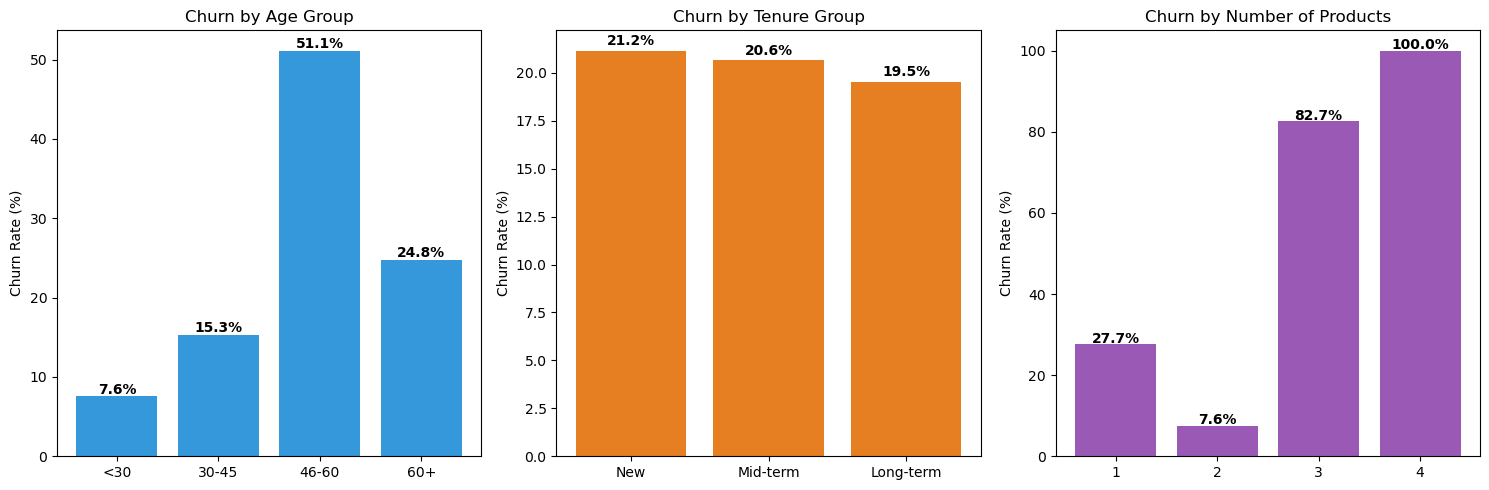

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age
axes[0].bar(age_churn.index, age_churn.values, color='#3498db')
axes[0].set_title('Churn by Age Group')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(age_churn.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Tenure
axes[1].bar(tenure_churn.index, tenure_churn.values, color='#e67e22')
axes[1].set_title('Churn by Tenure Group')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(tenure_churn.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Products
axes[2].bar(product_churn.index.astype(str), product_churn.values, color='#9b59b6')
axes[2].set_title('Churn by Number of Products')
axes[2].set_ylabel('Churn Rate (%)')
for i, v in enumerate(product_churn.values):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/age_tenure_product_churn.png', dpi=150)
plt.show()

#Age × Geography heatmap

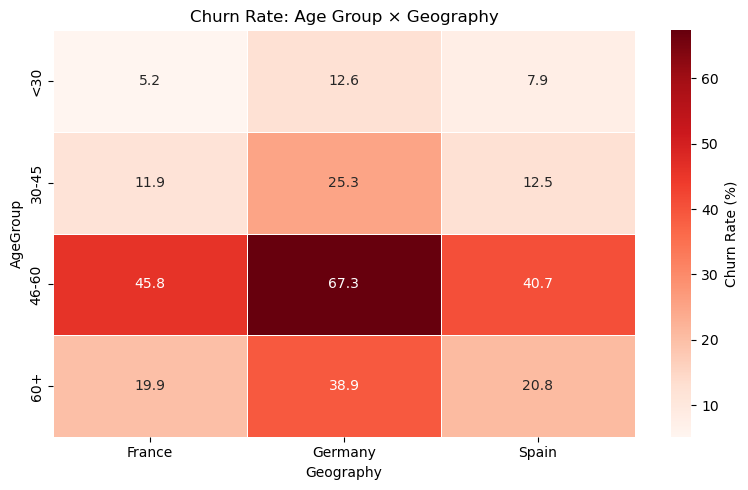

In [24]:
pivot = df.pivot_table('Exited', 'AgeGroup', 'Geography',
                        aggfunc='mean', observed=True) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate: Age Group × Geography')
plt.tight_layout()
plt.savefig('../assets/age_geo_heatmap.png', dpi=150)
plt.show()

#High-value churn numbers

In [25]:
hv_churn = df[df['IsHighValue']==1]['Exited'].mean() * 100
non_hv_churn = df[df['IsHighValue']==0]['Exited'].mean() * 100
hv_balance_risk = df[(df['IsHighValue']==1) & 
                     (df['Exited']==1)]['Balance'].sum()

print(f"High-Value Churn Rate   : {hv_churn:.1f}%")
print(f"Non High-Value Churn    : {non_hv_churn:.1f}%")
print(f"Total Balance at Risk   : £{hv_balance_risk:,.0f}")
print(f"Average Balance at Risk : £{df[(df['IsHighValue']==1) & (df['Exited']==1)]['Balance'].mean():,.0f}")

High-Value Churn Rate   : 23.7%
Non High-Value Churn    : 19.3%
Total Balance at Risk   : £88,654,932
Average Balance at Risk : £149,755


#Visualise high-value vs non high-value

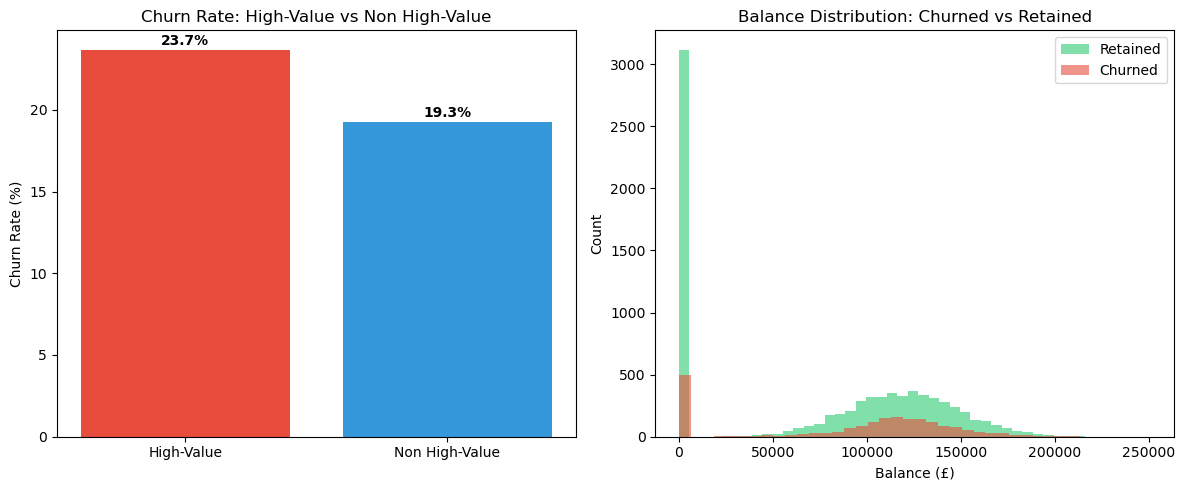

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate comparison
axes[0].bar(['High-Value', 'Non High-Value'],
            [hv_churn, non_hv_churn],
            color=['#e74c3c', '#3498db'])
axes[0].set_title('Churn Rate: High-Value vs Non High-Value')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate([hv_churn, non_hv_churn]):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Balance distribution churned vs retained
axes[1].hist(df[df['Exited']==0]['Balance'], bins=40,
             alpha=0.6, color='#2ecc71', label='Retained')
axes[1].hist(df[df['Exited']==1]['Balance'], bins=40,
             alpha=0.6, color='#e74c3c', label='Churned')
axes[1].set_title('Balance Distribution: Churned vs Retained')
axes[1].set_xlabel('Balance (£)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/highvalue_churn.png', dpi=150)
plt.show()

#Balance segment churn

BalanceSegment
Zero    13.8
Low     34.7
High    24.0
Name: Exited, dtype: float64


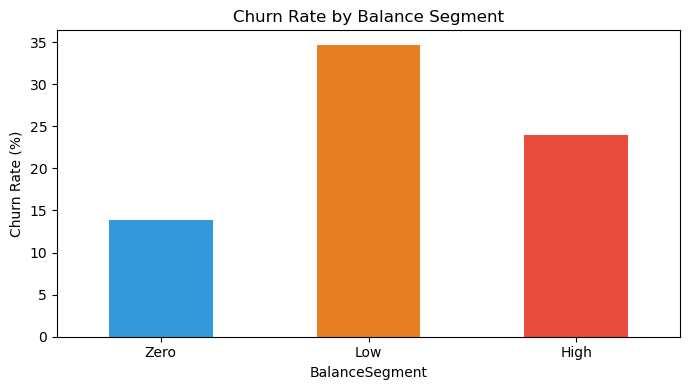

In [27]:
bal_churn = df.groupby('BalanceSegment', observed=True)['Exited'].mean() * 100
print(bal_churn.round(1))

bal_churn.plot(kind='bar', color=['#3498db','#e67e22','#e74c3c'],
               figsize=(7,4), rot=0)
plt.title('Churn Rate by Balance Segment')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../assets/balance_segment_churn.png', dpi=150)
plt.show()

#Consolidate all KPI's

In [28]:
kpis = {
    'Overall Churn Rate (%)':
        round(df['Exited'].mean() * 100, 1),
    'Total Churned Customers':
        int(df['Exited'].sum()),
    'Germany Churn Rate (%)':
        round(df[df['Geography']=='Germany']['Exited'].mean() * 100, 1),
    'Female Churn Rate (%)':
        round(df[df['Gender']=='Female']['Exited'].mean() * 100, 1),
    '46-60 Age Group Churn (%)':
        round(df[df['AgeGroup']=='46-60']['Exited'].mean() * 100, 1),
    'High-Value Churn Rate (%)':
        round(df[df['IsHighValue']==1]['Exited'].mean() * 100, 1),
    'Inactive Member Churn (%)':
        round(df[df['IsActiveMember']==0]['Exited'].mean() * 100, 1),
    'Balance at Risk (£M)':
        round(df[(df['IsHighValue']==1) &
                 (df['Exited']==1)]['Balance'].sum() / 1e6, 2)
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=['KPI', 'Value'])
print(kpi_df.to_string(index=False))

                      KPI   Value
   Overall Churn Rate (%)   20.40
  Total Churned Customers 2037.00
   Germany Churn Rate (%)   32.40
    Female Churn Rate (%)   25.10
46-60 Age Group Churn (%)   51.10
High-Value Churn Rate (%)   23.70
Inactive Member Churn (%)   26.90
     Balance at Risk (£M)   88.65


#Save KPIs to CSV for the dashboard

In [29]:
kpi_df.to_csv('../data/kpi_summary.csv', index=False)
print("KPI summary saved ✓")

KPI summary saved ✓
